# Togo — EDA Notebook

In [3]:
from pathlib import Path
import os

p = Path.cwd()
while not (p / "data").exists():
    p = p.parent
os.chdir(p)

print("Working directory set to:", os.getcwd())


Working directory set to: C:\KAIM Week-0\solar-challenge-week1


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"figure.figsize": (12, 5)})

RAW_PATH = "data/togo.csv"
CLEAN_PATH = "data/togo_clean.csv"

df = pd.read_csv(RAW_PATH, parse_dates=["Timestamp"])
df.sort_values("Timestamp", inplace=True)
df.reset_index(drop=True, inplace=True)

df.head()


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
1,2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2,2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
3,2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
4,2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


## 1. Summary Statistics

In [5]:

display(df.describe(include='all'))

na_counts = df.isna().sum()
na_pct = (na_counts / len(df) * 100).round(2)
display(pd.DataFrame({"Missing": na_counts, "Percent": na_pct}))


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-04-25 12:00:30.000000768,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
min,2021-10-25 00:01:00,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,2022-01-24 06:00:45,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2022-04-25 12:00:30,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,2022-07-25 18:00:15,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,2022-10-25 00:00:00,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN
std,NaN,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN


,Missing,Percent
Timestamp,0,0.0
GHI,0,0.0
DNI,0,0.0
DHI,0,0.0
ModA,0,0.0
ModB,0,0.0
Tamb,0,0.0
RH,0,0.0
WS,0,0.0
WSgust,0,0.0


## 2. Outlier Detection using Z-scores

In [6]:

numeric_cols = ["GHI","DNI","DHI","ModA","ModB","WS","WSgust"]

for col in numeric_cols:
    if col in df.columns:
        df[col+"_z"] = (df[col] - df[col].mean()) / df[col].std()

outlier_summary = {col: df[df[col+"_z"].abs() > 3].shape[0] for col in numeric_cols if col+"_z" in df.columns}
outlier_summary


{'GHI': 305,
 'DNI': 1062,
 'DHI': 3415,
 'ModA': 137,
 'ModB': 206,
 'WS': 3510,
 'WSgust': 3915}

## 3. Data Cleaning (Median Imputation)

In [7]:

key_cols = ["GHI","DNI","DHI","ModA","ModB","Tamb","RH","WS","WSgust","BP","TModA","TModB"]

for col in key_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

df.to_csv(CLEAN_PATH, index=False)
CLEAN_PATH


'data/togo_clean.csv'

## 4. Time Series Plots

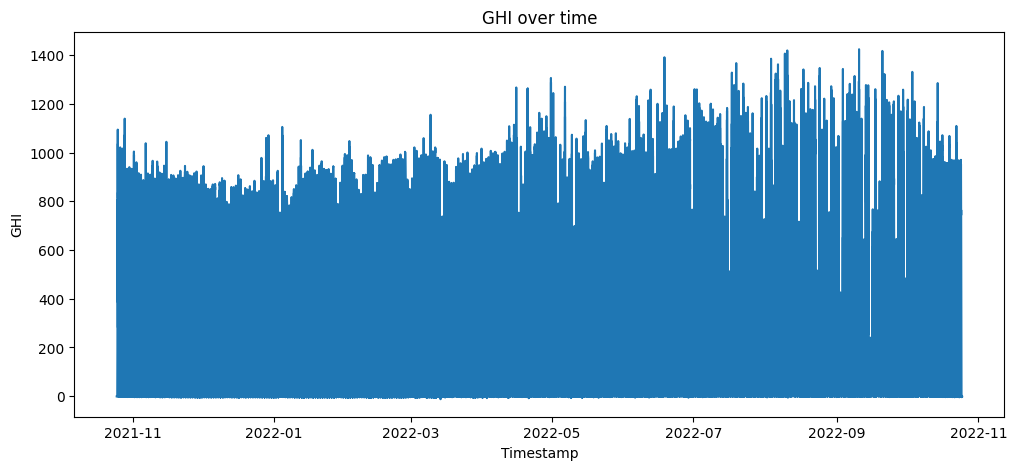

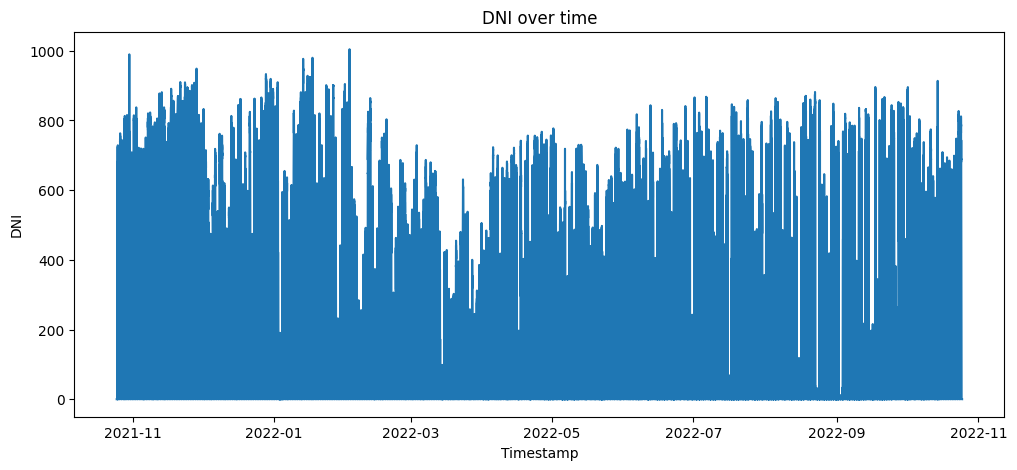

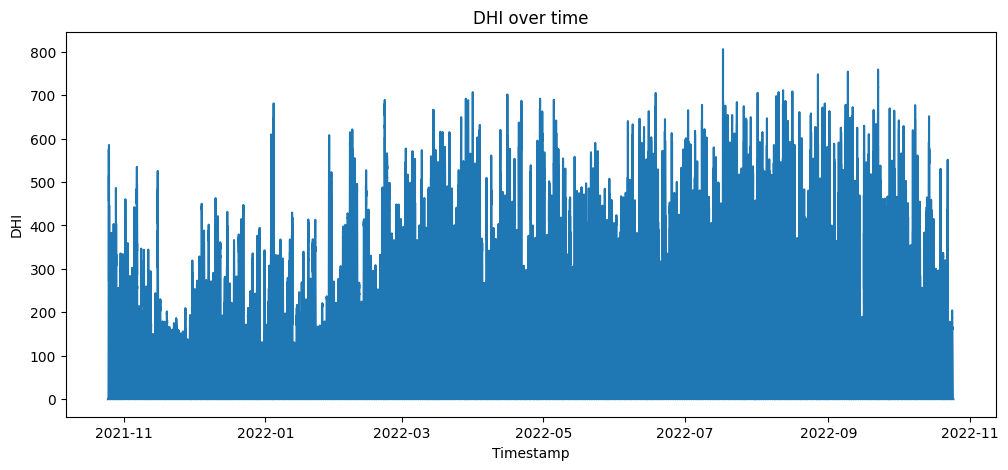

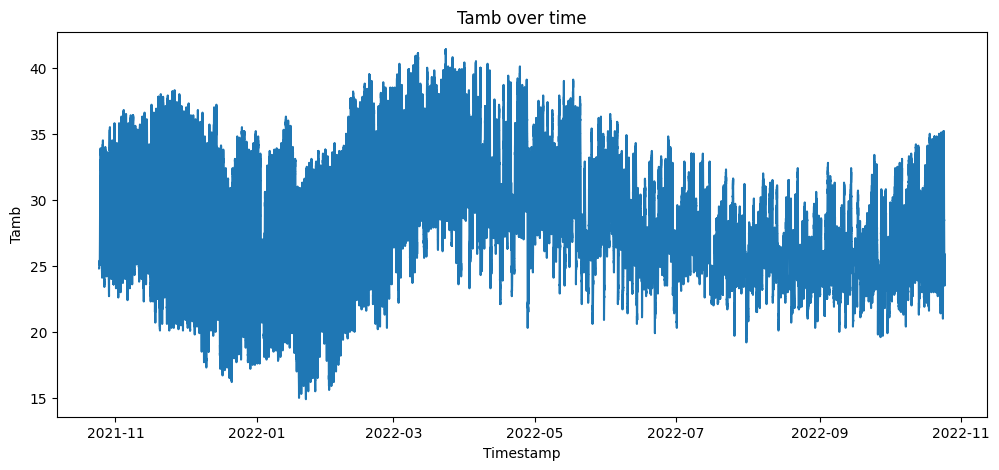

In [8]:

for col in ["GHI", "DNI", "DHI", "Tamb"]:
    if col in df.columns:
        plt.figure()
        plt.plot(df["Timestamp"], df[col])
        plt.title(f"{col} over time")
        plt.xlabel("Timestamp")
        plt.ylabel(col)
        plt.show()


## 5. Cleaning Impact on ModA & ModB

,ModA,ModB
Cleaning,,
0,225.979064,219.401351
1,535.186477,532.211744


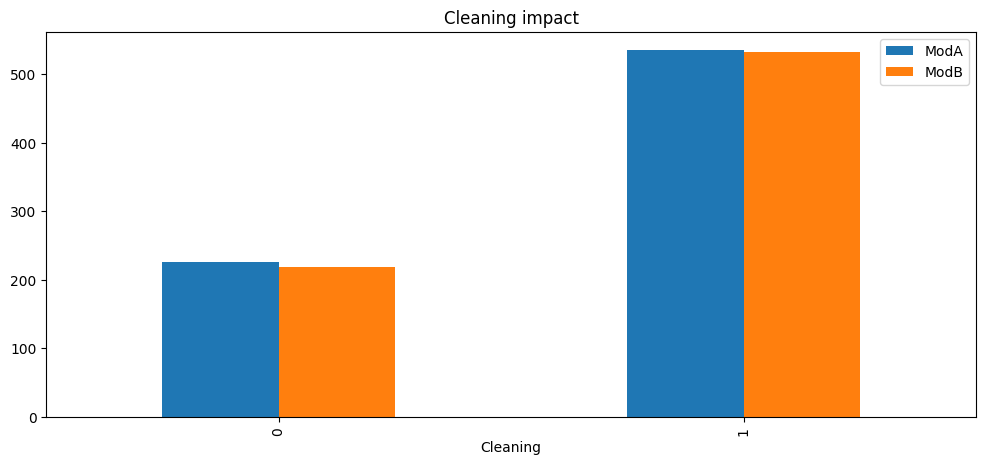

In [9]:

if "Cleaning" in df.columns:
    grp = df.groupby("Cleaning")[["ModA","ModB"]].mean()
    display(grp)
    grp.plot(kind="bar")
    plt.title("Cleaning impact")
    plt.show()


## 6. Correlation Heatmap

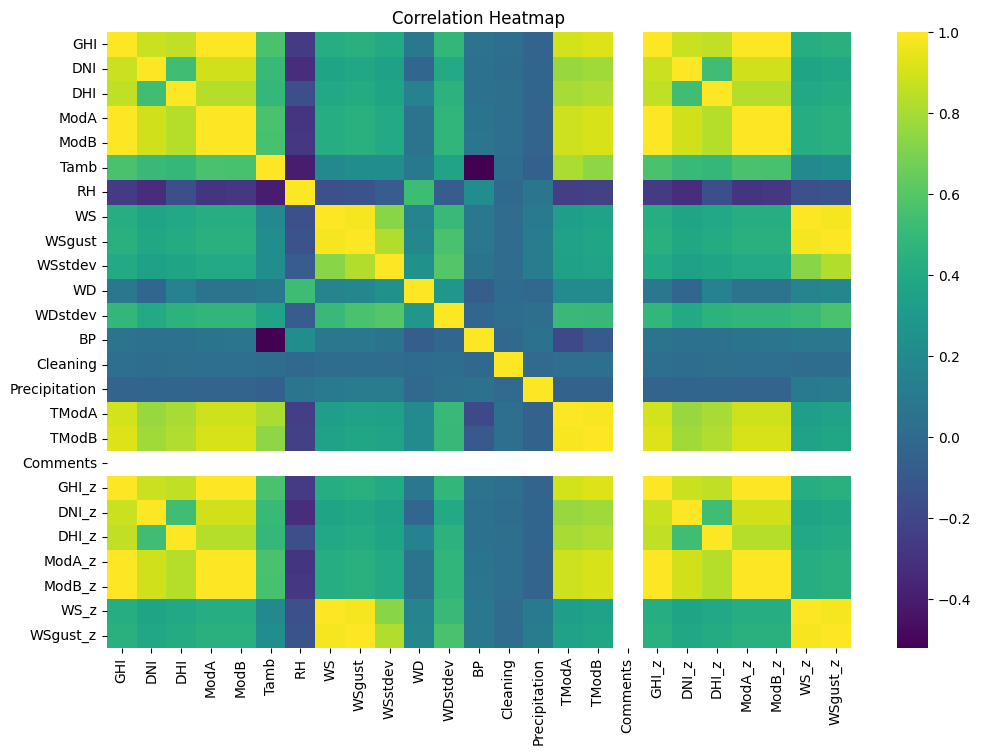

In [10]:

numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=False, cmap="viridis")
plt.title("Correlation Heatmap")
plt.show()


## 7. Scatter Plots

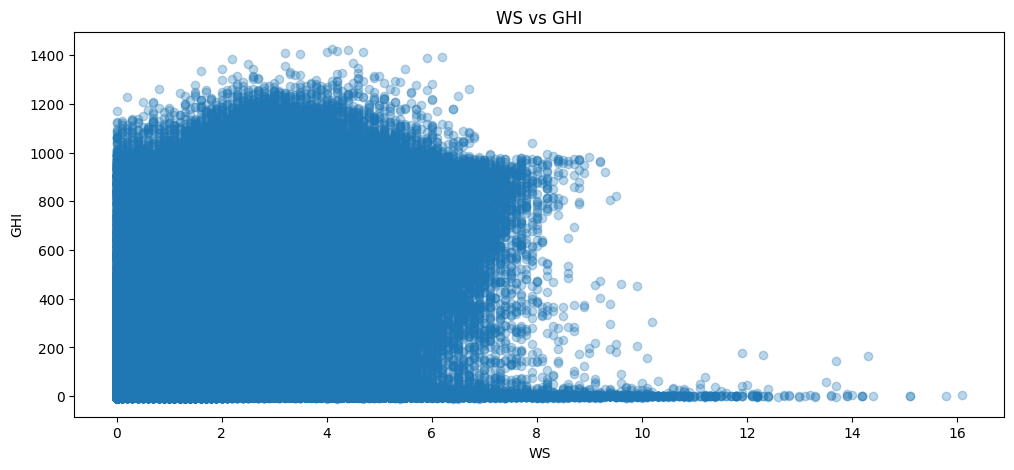

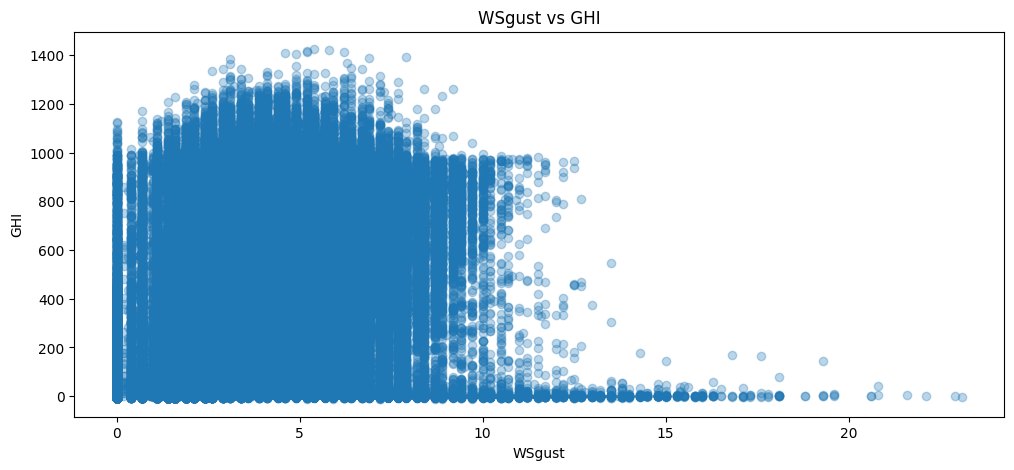

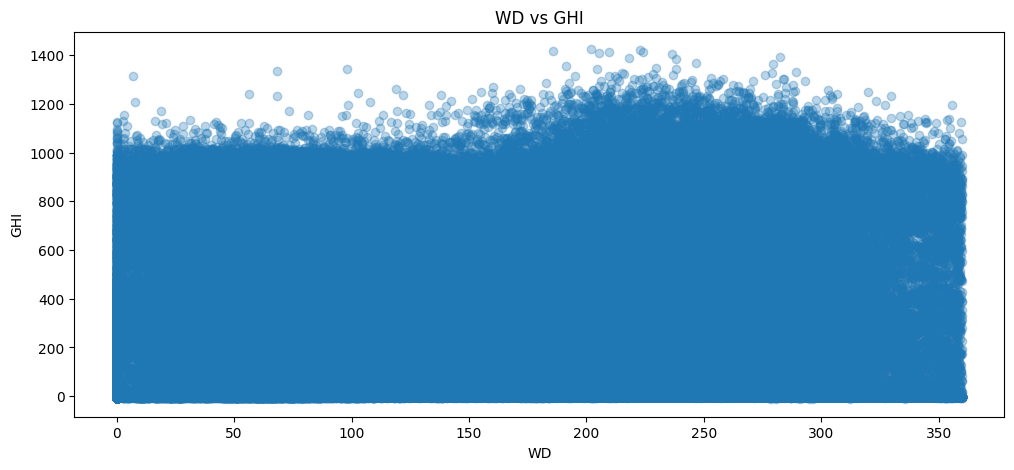

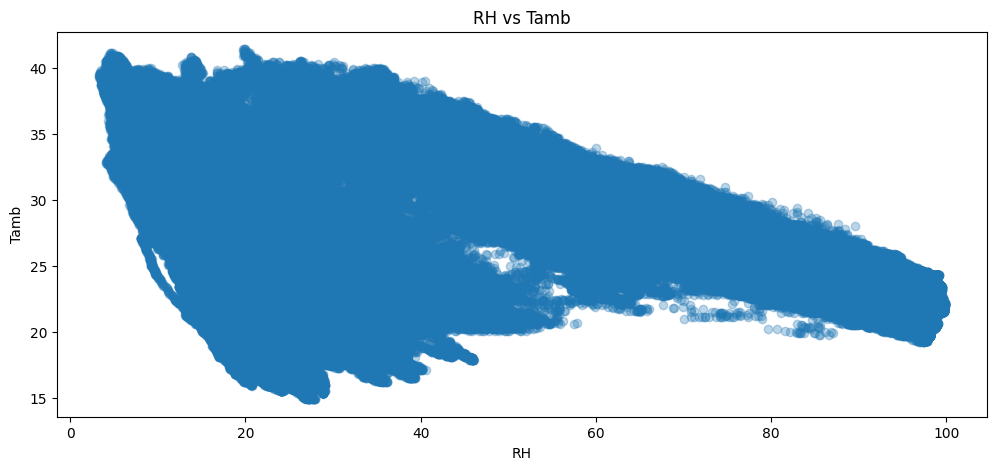

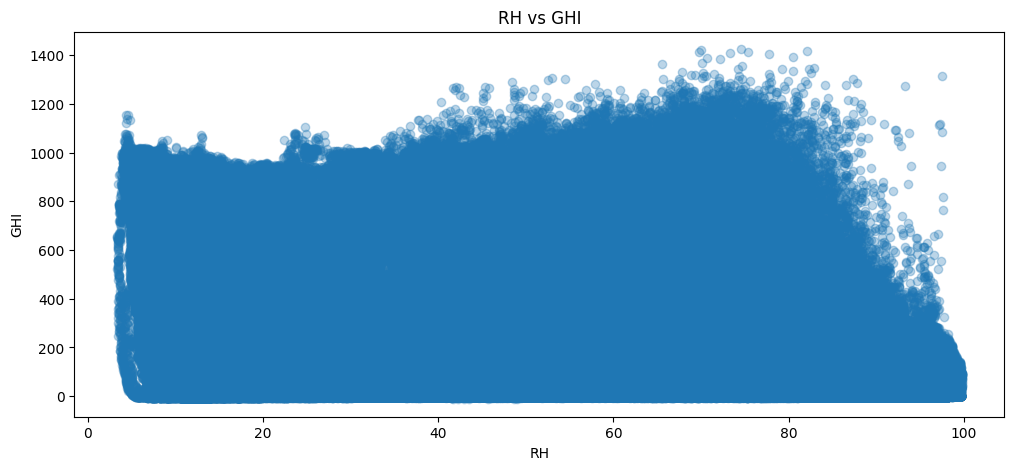

In [11]:

pairs = [("WS","GHI"), ("WSgust","GHI"), ("WD","GHI"), ("RH","Tamb"), ("RH","GHI")]

for x,y in pairs:
    if x in df.columns and y in df.columns:
        plt.figure()
        plt.scatter(df[x], df[y], alpha=0.3)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f"{x} vs {y}")
        plt.show()


## 8. Histograms

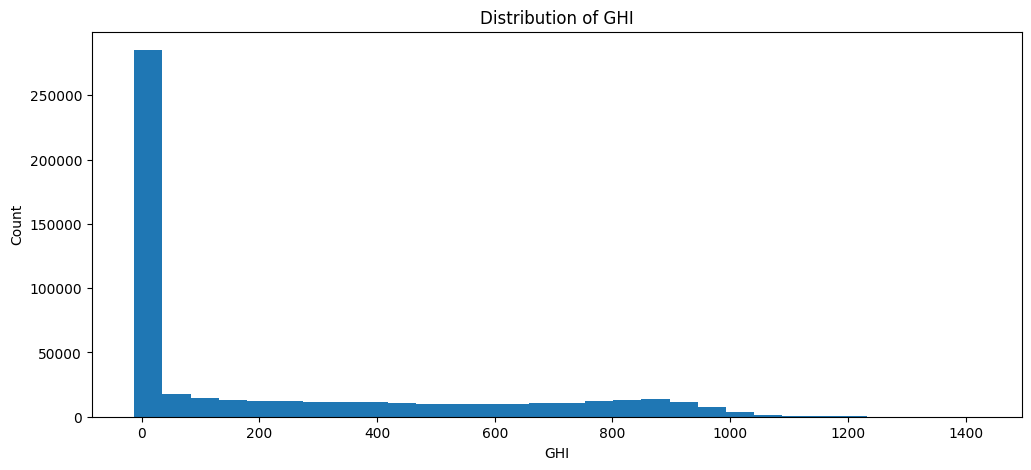

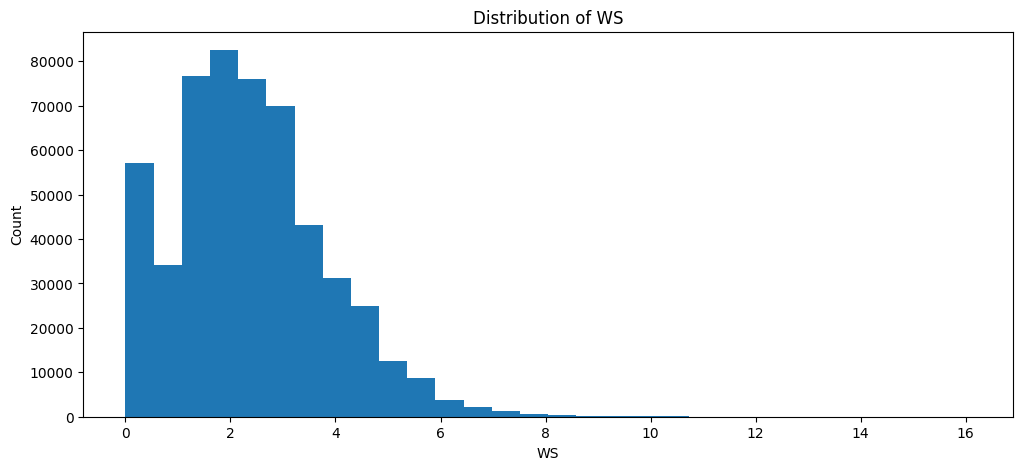

In [12]:

for col in ["GHI","WS"]:
    if col in df.columns:
        plt.figure()
        plt.hist(df[col], bins=30)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()


## 9. Wind Rose Plot

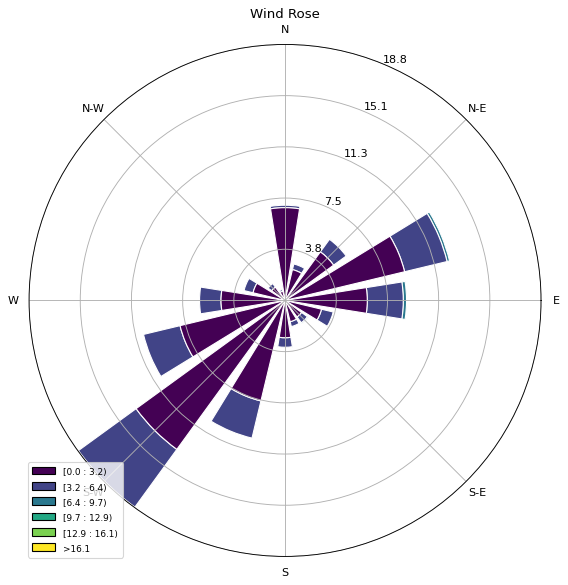

In [13]:

try:
    from windrose import WindroseAxes
    if "WS" in df.columns and "WD" in df.columns:
        ax = WindroseAxes.from_ax()
        ax.bar(df["WD"], df["WS"], normed=True, opening=0.8, edgecolor='white')
        ax.set_legend()
        plt.title("Wind Rose")
        plt.show()
except Exception as e:
    print("Windrose not available:", e)


## 10. Bubble Chart (GHI vs Tamb, bubble = RH)

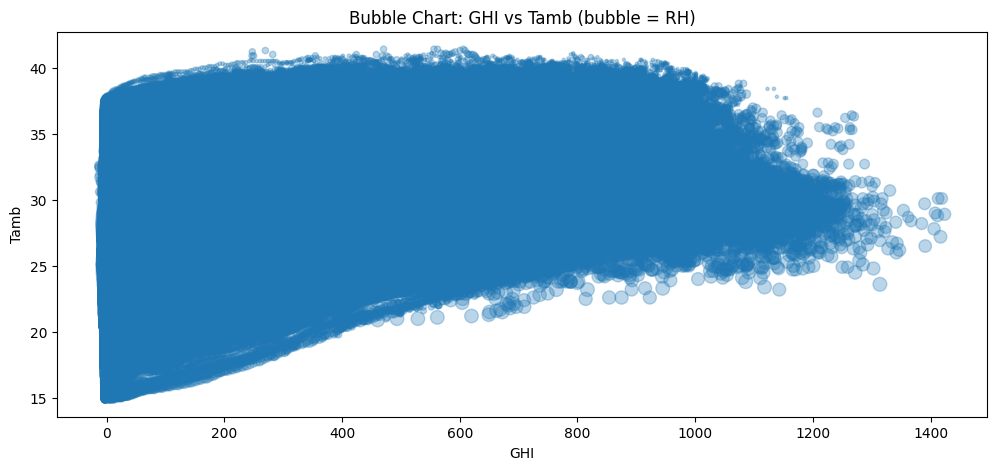

In [14]:

if "GHI" in df.columns and "Tamb" in df.columns and "RH" in df.columns:
    plt.figure()
    plt.scatter(df["GHI"], df["Tamb"], s=df["RH"]+1, alpha=0.3)
    plt.xlabel("GHI")
    plt.ylabel("Tamb")
    plt.title("Bubble Chart: GHI vs Tamb (bubble = RH)")
    plt.show()
